# Unsupervised Learning, Dimensionality Reduction
Summary: This project covers some unsupervised learning tasks, focusing on dimensionality reduction.

In [ ]:
%pip install optuna

In [3]:
import os

import tensorflow as tf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding

import umap
import optuna
import time

from PIL import Image
import cv2

## Task 1. Answer the questions from the Preamble and Introduction
1. For which of the models already studied is the curse of dimensionality relevant and explain why.


    The curse of dimensionality is most critical for the KNN and K-means algorithms. Both algorithms are based on Euclidean (or Manhattan) distance. In a multidimensional space, all points become nearly equidistant from one another (distances cease to be informative).
2. What is the difference between PCA and SVD?


    PCA is mathematically equivalent to applying SVD to the centered data matrix. Sklearn use the SVD under the hood to compute PCA.
3. What is the difference between NMF and SVD?


    NMF cannot be applied to data that contains negative values (for example, centered data with negative deviations). It requires data such as image pixels, word frequencies (TF-IDF), or counts (for example, the number of purchases). The main advantage of NMF is its high interpretability.
4. Describe the structure of the Locally Linear Embedding dimension reduction algorithm.


    * For each point xi in the original high-dimensional space, we need to find its K nearest neighbors.
    * For each point xi, we seek weights wij such that this point can be reconstructed as a linear combination of its neighbors xj.
    * We transfer these same weights wij to the low-dimensional space. This reduces to solving the eigenvector problem for a sparse matrix. The solution will be the eigenvectors corresponding to the smallest (nonzero) eigenvalues.

## Task 2. Classification with Sparse Features

1) Load the "Book Recommendation Dataset" (source).

In [ ]:
users = pd.read_csv('data/Users.csv')
ratings = pd.read_csv('data/Ratings.csv')

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [ ]:
print(f'Unique users in Ratings: {ratings["User-ID"].nunique()}')
print(f'Unique users in Users: {users["User-ID"].nunique()}')

Unique users in Ratings: 105283
Unique users in Users: 278858


2) Create a matrix of user-book interactions. Using Sparse Matrices.


In [ ]:
users_clean = users[users['Age'].notna()].copy()

low_ = users.Age.quantile(.01)
high_ = users.Age.quantile(.99)

users_clean = users_clean[(users_clean['Age'] >= low_) & (users_clean['Age'] <= high_)]

merged = pd.merge(users_clean, ratings, on='User-ID', how='inner')

print(f'Merged matrix shape: {merged.shape}')

Merged matrix shape: (825801, 5)


In [ ]:
user_codes = merged['User-ID'].astype('category').cat.codes
book_codes = merged['ISBN'].astype('category').cat.codes
n_users = user_codes.nunique()
n_books = book_codes.nunique()

sparse_matrix = coo_matrix(
    (np.ones(len(merged), dtype=np.int8), (user_codes, book_codes)),
    shape=(n_users, n_books)
).tocsr()

print(f'Sparse matrix shape: {sparse_matrix.shape}')
print(f'Matrix Density: {sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]):.6f}')

Sparse matrix shape: (60790, 281198)
Matrix Density: 0.000048


In [ ]:
age_target = merged.groupby('User-ID')['Age'].first().values

print(f'Target shape: {age_target.shape}')

Target shape: (60790,)


3) Split the dataset into training, valid, and test parts.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sparse_matrix, age_target,
                                                    test_size=0.33, random_state=21)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.33, random_state=21)

4) Build linear and random forest models to predict user age based on user-book interactions. Do not forget to choose optimal parameters.


In [ ]:
def run_study(objective_fn, name, n_trials=100):
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=21),
        study_name=name,
        pruner=optuna.pruners.MedianPruner()
    )
    study.optimize(
        objective_fn,
        n_trials=n_trials,
        show_progress_bar=True,
    )
    print(f'\n[{name}] best R2 : {study.best_value:.5f}')
    print(f'[{name}] best params: {study.best_params}')
    return study

### Ridge Optuna

In [ ]:
def ridge_objective(trial, X_train, y_train, X_val, y_val):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-3, 100.0, log=True),
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False]),
        'solver': trial.suggest_categorical('solver', ['lsqr', 'sparse_cg']),
        'tol': trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        'random_state': 21,
    }

    model = Ridge(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    return r2

In [ ]:
ridge_study = run_study(
    lambda trial: ridge_objective(trial, X_train, y_train,
                                       X_val, y_val),
    name="Ridge", n_trials=50,
)

### Random Forest Optuna

In [ ]:
def rf_objective(trial, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100, step=10),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_weight_fraction_leaf': trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 100, step=10),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 21,
        'n_jobs': -1,
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    return r2

In [ ]:
rf_study = run_study(
    lambda trial: rf_objective(trial, X_train, y_train,
                                       X_val, y_val),
    name="Random Forest", n_trials=5,
)

### Results

In [ ]:
for study, name in [(ridge_study, 'Ridge'),
                    (rf_study, 'Random Forest')]:
    print(f'{name:15s}  R2 = {study.best_value:.4f}')

Ridge            R2 = 0.0283
Random Forest    R2 = -0.0000


5) Use PCA and UMAP to reduce the dimensionality of the features.
6) Build linear model and random forest model on the compressed features.

### PCA

In [ ]:
pca = TruncatedSVD(
        n_components=100,
        random_state=21,
        algorithm='randomized'
    )

pca_matrix = pca.fit_transform(X_train)

In [ ]:
X_val_pca = pca.transform(X_val)

In [ ]:
ridge_study_pca = run_study(
    lambda trial: ridge_objective(trial, pca_matrix, y_train,
                                       X_val_pca, y_val),
    name="Ridge PCA", n_trials=50,
)

In [ ]:
rf_study_pca = run_study(
    lambda trial: rf_objective(trial, pca_matrix, y_train,
                                       X_val_pca, y_val),
    name="Random Forest", n_trials=5,
)

### UMAP

In [ ]:
reducer = umap.UMAP(n_components=100)
embedding = reducer.fit_transform(X_train)

In [ ]:
X_val_umap = reducer.transform(X_val)

In [ ]:
ridge_study_umap = run_study(
    lambda trial: ridge_objective(trial, embedding, y_train,
                                       X_val_umap, y_val),
    name="Ridge UMAP", n_trials=50,
)

In [ ]:
rf_study_umap = run_study(
    lambda trial: rf_objective(trial, embedding, y_train,
                                       X_val_umap, y_val),
    name="Random Forest UMAP", n_trials=5,
)

7) Compare fitting time and quality for models from iv and vi.

In [ ]:
def fit_model(model, X_train, y_train, X_test, y_test) -> tuple[float, float]:
  start = time.time()
  model.fit(X_train, y_train)
  fit_time = time.time() - start

  y_pred = model.predict(X_test)
  r2 = r2_score(y_test, y_pred)

  return fit_time, r2

In [ ]:
X_test_pca = pca.transform(X_test)
X_test_umap = reducer.transform(X_test)

In [ ]:
results = {}

models = {
    'Ridge': [Ridge(**ridge_study.best_params), X_train, X_test],
    'Random Forest': [RandomForestRegressor(**rf_study.best_params), X_train, X_test],
    'Ridge PCA': [Ridge(**ridge_study_pca.best_params), pca_matrix, X_test_pca],
    'Random Forest PCA': [RandomForestRegressor(**rf_study_pca.best_params), pca_matrix, X_test_pca],
    'Ridge UMAP': [Ridge(**ridge_study_umap.best_params), embedding, X_test_umap],
    'Random Forest UMAP': [RandomForestRegressor(**rf_study_umap.best_params), embedding, X_test_umap]
}


for k, v in models.items():
  model, train, test = v
  time_, r2 = fit_model(model, train, y_train, test, y_test)

  results[k] = {
      'Fit time': time_,
      'R2': r2
  }

In [ ]:
pd.DataFrame(results)

,Ridge,Random Forest,Ridge PCA,Random Forest PCA,Ridge UMAP,Random Forest UMAP
Fit time,0.529838,78.298751,0.113894,42.761556,0.013915,32.293818
R2,0.020446,-0.000048,0.006472,0.040617,0.000375,0.000986


## Task 3. Visualizations
1) Load the MNIST dataset.

In [ ]:
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2) Represent each digit image as a vector.

In [ ]:
mnist_x_train_vectors = mnist_x_train.reshape(mnist_x_train.shape[0], -1)

mnist_x_test_vectors = mnist_x_test.reshape(mnist_x_test.shape[0], -1)
print(mnist_x_train_vectors.shape)
print(mnist_x_test_vectors.shape)

(60000, 784)
(10000, 784)


3) Transform vectors up to 2 dimensions using PCA, SVD, Randomized-SVD, TSNE, UMAP, and LLE.

  subsample

In [ ]:
n_samples = 3000
rng = np.random.RandomState(21)
idx = rng.choice(mnist_x_train_vectors.shape[0], n_samples, replace=False)

X_sample = mnist_x_train_vectors[idx]
y_sample = mnist_y_train[idx]

transform

In [ ]:
results = {}

#pca
start = time.time()
pca = PCA(n_components=2, random_state=21)
results['PCA'] = (pca.fit_transform(X_sample), time.time() - start)

#svd
start = time.time()
svd = TruncatedSVD(n_components=2, algorithm='arpack', random_state=21)
results['SVD'] = (svd.fit_transform(X_sample), time.time() - start)

# randomized svd
start = time.time()
rsvd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=21)
results['Randomized SVD'] = (rsvd.fit_transform(X_sample), time.time() - start)

# t-sne
start = time.time()
tsne = TSNE(n_components=2, random_state=21, init='pca')
results['t-SNE'] = (tsne.fit_transform(X_sample), time.time() - start)

# umap
start = time.time()
reducer = umap.UMAP(n_components=2, random_state=21)
results['UMAP'] = (reducer.fit_transform(X_sample), time.time() - start)

# lle
start = time.time()
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=21)
results['LLE'] = (lle.fit_transform(X_sample), time.time() - start)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


plot

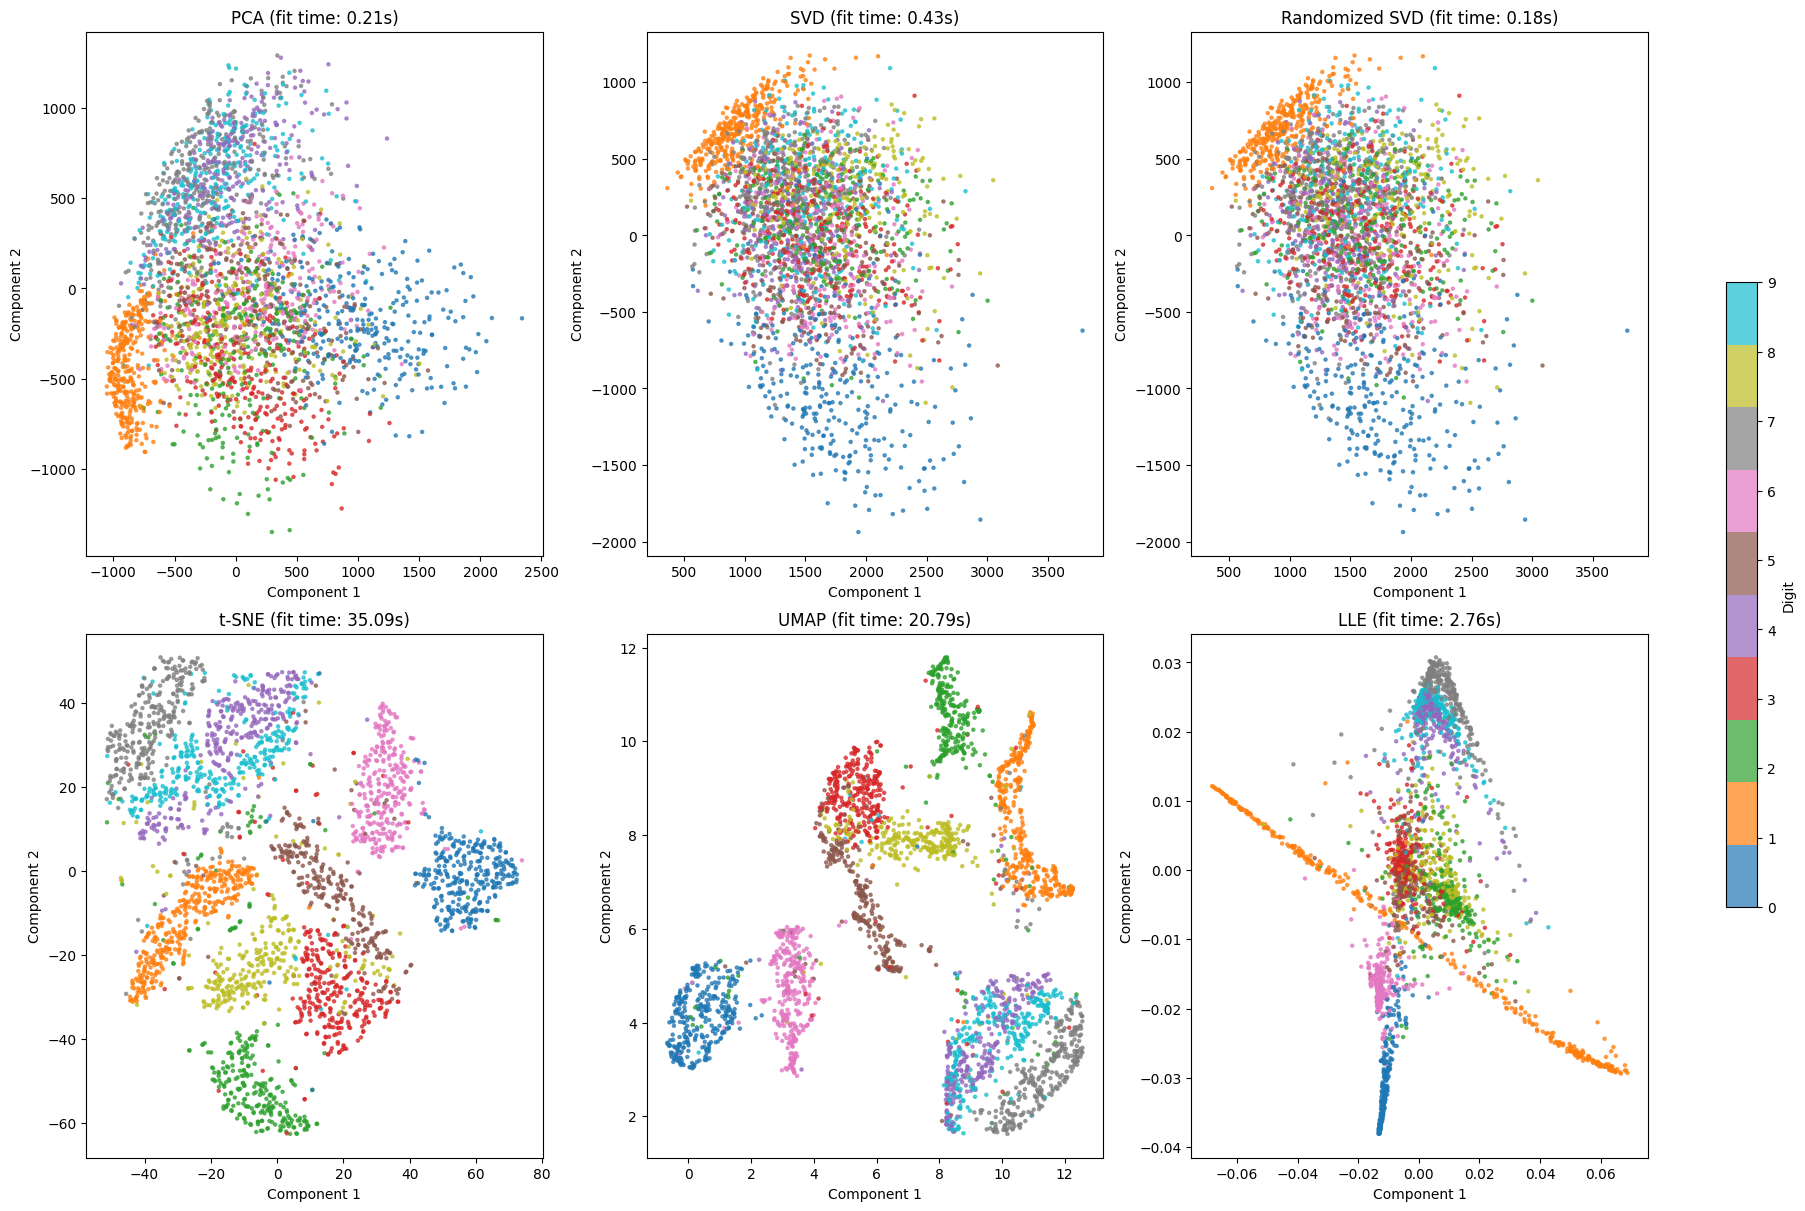

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten()

for ax, (name, (embedding, fit_time)) in zip(axes, results.items()):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                          c=y_sample.astype(int), cmap='tab10', s=5, alpha=0.7)
    ax.set_title(f'{name} (fit time: {fit_time:.2f}s)')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

fig.colorbar(scatter, ax=axes, label='Digit', fraction=0.02)
plt.show()

## Task 4. Image compression using SVD
1) Select 3 random grayscale images and load them into matrix using Python.

In [ ]:
filenames = ['data/stock_image_1.jpg', 'data/stock_image_2.jpg', 'data/stock_image_3.jpg']

images = []
for fname in filenames:
    img = Image.open(fname).convert('L')
    img_array = np.array(img)
    images.append(img_array)
    print(fname, img_array.shape)

data/stock_image_1.jpg (705, 1024)
data/stock_image_2.jpg (5069, 3379)
data/stock_image_3.jpg (4089, 6133)


2) Decompose the matrix using SVD.

In [ ]:
svd_results = []

for img in images:
    A = img.astype(np.float64)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    svd_results.append((U, S, Vt, A))
    print(f'Image shape: {A.shape}, singular values: {len(S)}')

Image shape: (705, 1024), singular values: 705
Image shape: (5069, 3379), singular values: 3379
Image shape: (4089, 6133), singular values: 4089


3) Vary the rank, compute a low-rank approximation of the original matrix, and plot the recovered image. Use up to 10 different ranks. What does the singular value spectrum look like and how many modes are needed for good image reconstruction?

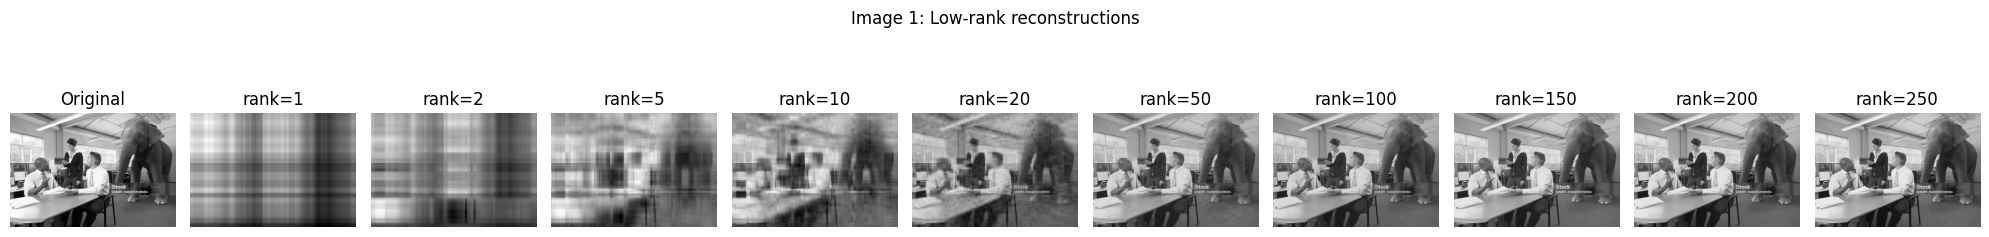

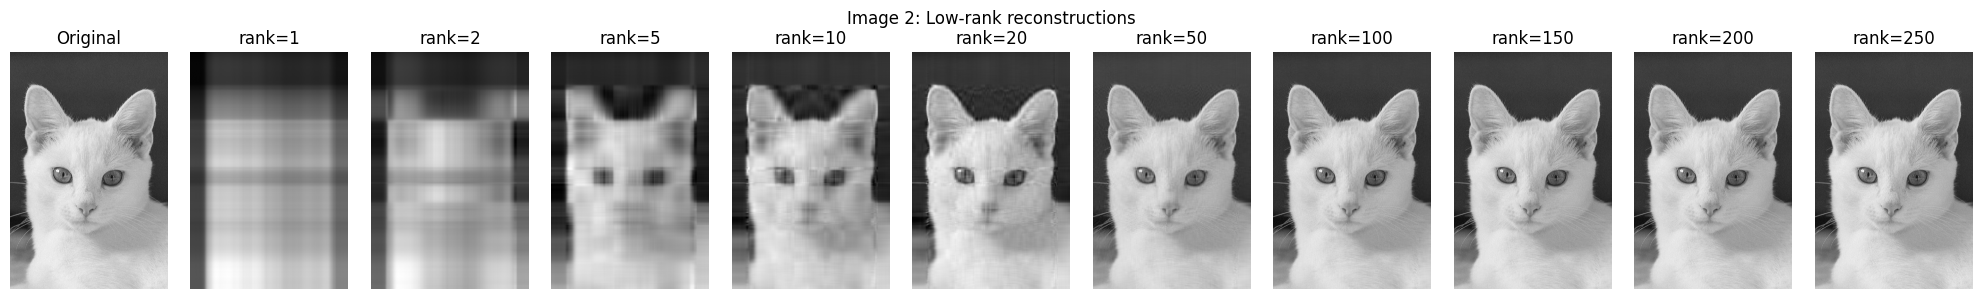

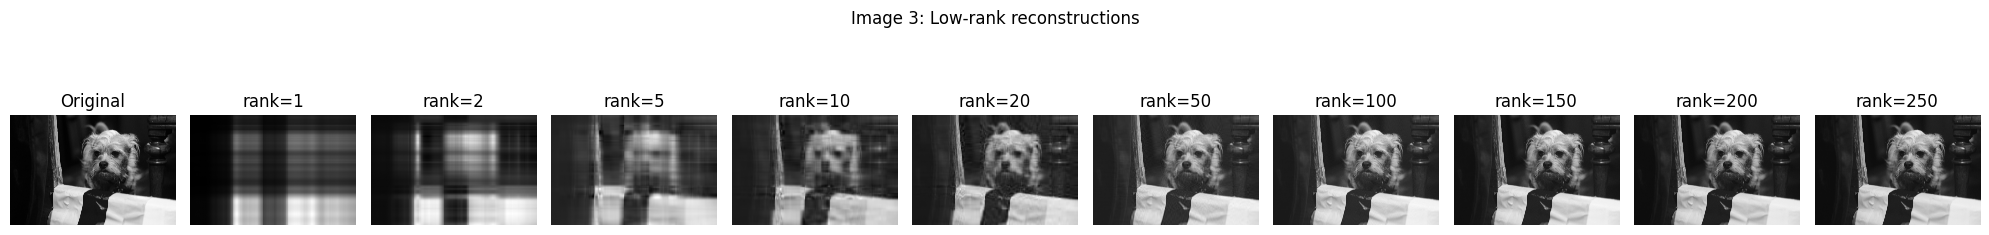

In [ ]:
def low_rank_approx(U, S, Vt, k):
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

ranks = [1, 2, 5, 10, 20, 50, 100, 150, 200, 250]

for img_idx, (U, S, Vt, A) in enumerate(svd_results):
    valid_ranks = [r for r in ranks if r <= len(S)]

    fig, axes = plt.subplots(1, len(valid_ranks) + 1, figsize=(20, 3))

    axes[0].imshow(A, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    for ax, k in zip(axes[1:], valid_ranks):
        A_k = low_rank_approx(U, S, Vt, k)
        ax.imshow(A_k, cmap='gray')
        ax.set_title(f'rank={k}')
        ax.axis('off')

    plt.suptitle(f'Image {img_idx+1}: Low-rank reconstructions')
    plt.tight_layout()
    plt.show()

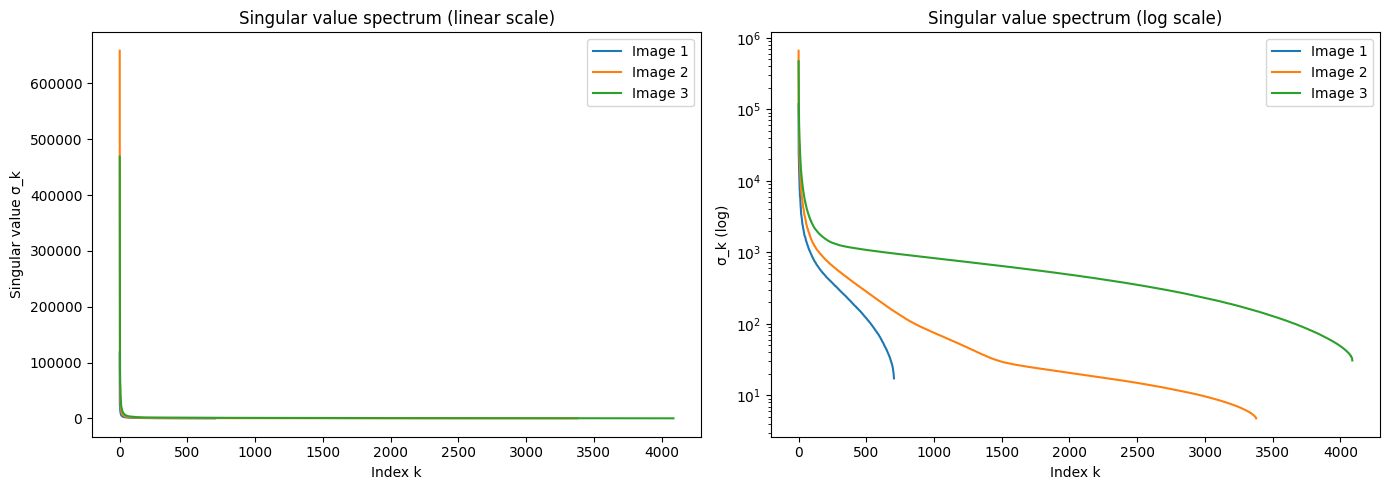

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for img_idx, (U, S, Vt, A) in enumerate(svd_results):
    axes[0].plot(S, label=f'Image {img_idx+1}')
    axes[1].semilogy(S, label=f'Image {img_idx+1}')

axes[0].set_title('Singular value spectrum (linear scale)')
axes[0].set_xlabel('Index k')
axes[0].set_ylabel('Singular value σ_k')
axes[0].legend()

axes[1].set_title('Singular value spectrum (log scale)')
axes[1].set_xlabel('Index k')
axes[1].set_ylabel('σ_k (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

4) Plot the distribution of explained variance versus rank. Explain what "explained variance" is.

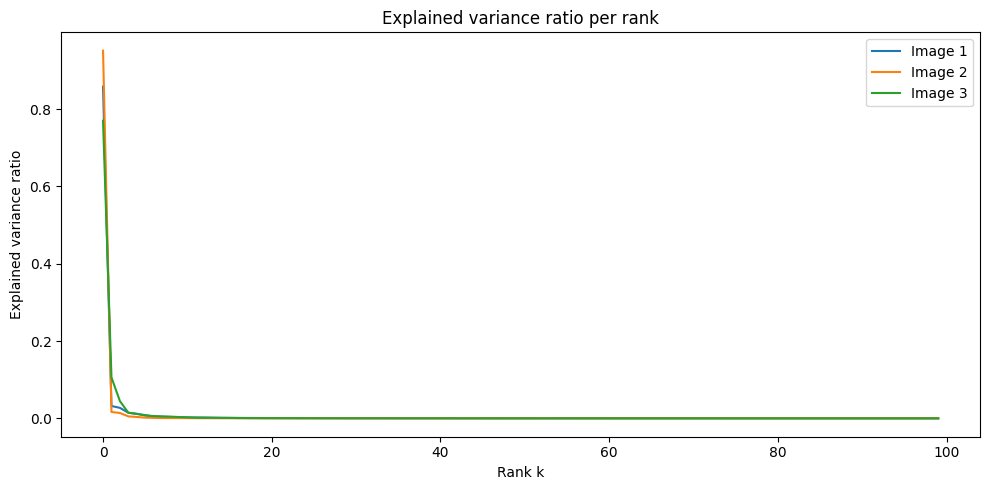

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for img_idx, (U, S, Vt, A) in enumerate(svd_results):
    explained_variance_ratio = (S ** 2) / np.sum(S ** 2)

    ax.plot(explained_variance_ratio[:100], label=f'Image {img_idx+1}')

ax.set_title('Explained variance ratio per rank')
ax.set_xlabel('Rank k')
ax.set_ylabel('Explained variance ratio')
ax.legend()


plt.tight_layout()
plt.show()

## Task 5. Background detection using SVD
1) Load "Video_008.avi" (source — bmc_real.zip).

In [ ]:
cap = cv2.VideoCapture('data/Video_008.avi')

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray)

cap.release()

frames = np.array(frames)
print(frames.shape)

(792, 240, 320)


2) Represent the video as a matrix and decompose it using SVD.

In [ ]:
n_frames, h, w = frames.shape

X = frames.reshape(n_frames, h * w).T.astype(np.float64)
print(f'(h*w, n_frames): {X.shape}')

U, S, Vt = np.linalg.svd(X, full_matrices=False)
print(f'U.shape: {U.shape}, S.shape: {S.shape}, Vt.shape: {Vt.shape}')

(h*w, n_frames): (76800, 792)
U.shape: (76800, 792), S.shape: (792,), Vt.shape: (792, 792)


3) Reconstruct the first frame using low-rank approximation. What rank should you use to get the background?

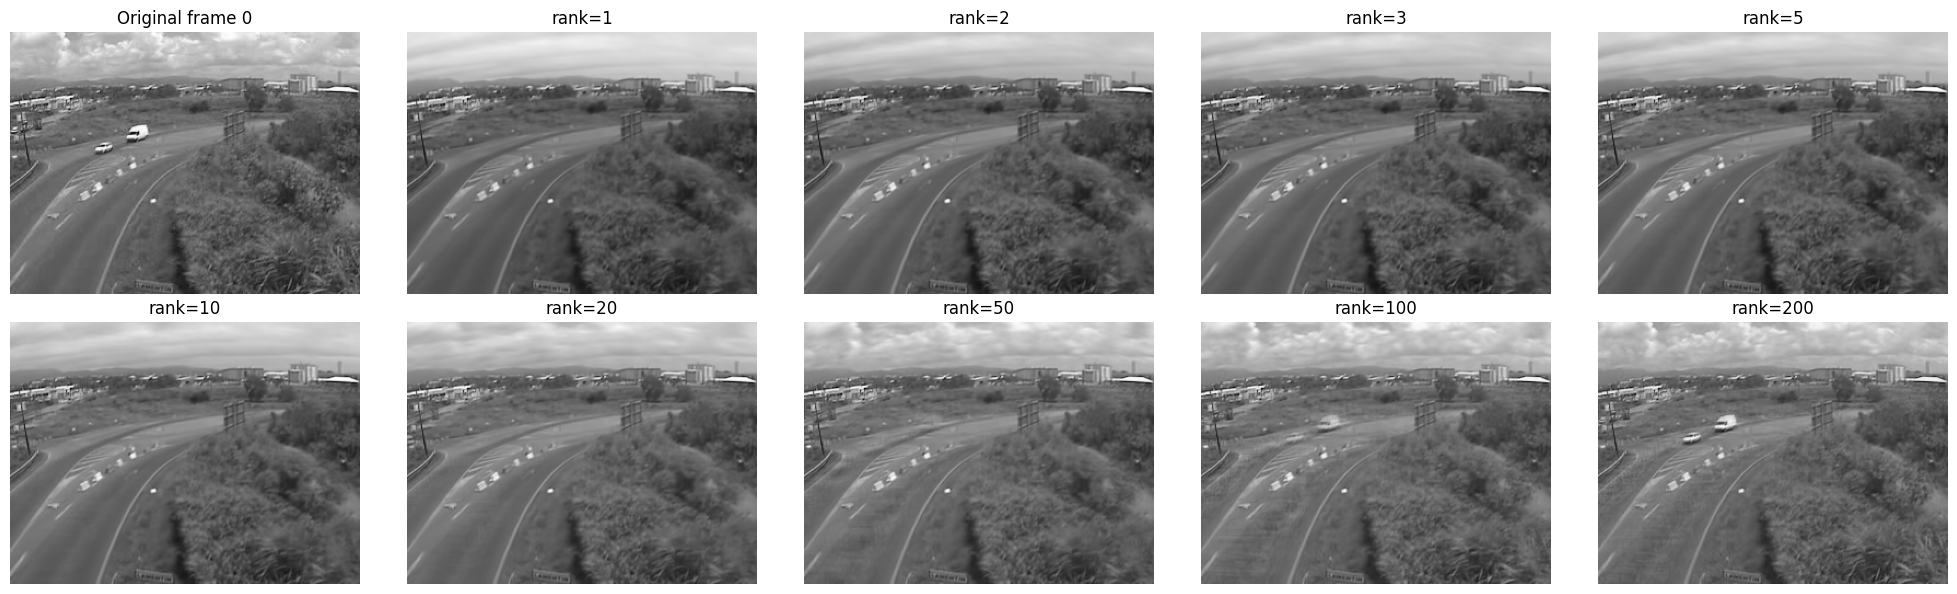

In [ ]:
import matplotlib.pyplot as plt

ranks = [1, 2, 3, 5, 10, 20, 50, 100, 200]
ranks = [r for r in ranks if r <= len(S)]

fig, axes = plt.subplots(2, len(ranks)//2 + 1, figsize=(20, 6))
axes = axes.flatten()

axes[0].imshow(frames[0], cmap='gray')
axes[0].set_title('Original frame 0')
axes[0].axis('off')

for i, k in enumerate(ranks):
    frame0_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, 0]
    frame0_k_img = frame0_k.reshape(h, w)

    axes[i+1].imshow(frame0_k_img, cmap='gray')
    axes[i+1].set_title(f'rank={k}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## Task 6. Bonus Part


Using the face expression recognition dataset, fit the dimensionality reduction model to compress faces. Using the representations, try to turn a sad face into a smiley face and vice versa.

In [4]:
data_dir = 'data'
emotions = ['happy', 'sad']

images = {}
for emotion in emotions:
    folder = os.path.join(data_dir, emotion)
    files = os.listdir(folder)
    imgs = []
    for fname in files:
        img = Image.open(os.path.join(folder, fname)).convert('L')
        imgs.append(np.array(img).flatten())
    images[emotion] = np.array(imgs)
    print(emotion, images[emotion].shape)

happy (4815, 2304)
sad (4932, 2304)


### PCA

In [28]:
X_all = np.vstack([images['happy'], images['sad']])

pca = PCA(n_components=500, random_state=21)
pca.fit(X_all)

happy_pca = pca.transform(images['happy'])
sad_pca = pca.transform(images['sad'])

### Direction

In [29]:
happy_mean = happy_pca.mean(axis=0)
sad_mean = sad_pca.mean(axis=0)

direction_sad_to_happy = happy_mean - sad_mean

### Sad -> Happy

In [31]:
def reconstruct(latent_vector, pca, shape=(48, 48)):
    img_flat = pca.inverse_transform(latent_vector)
    return img_flat.reshape(shape)

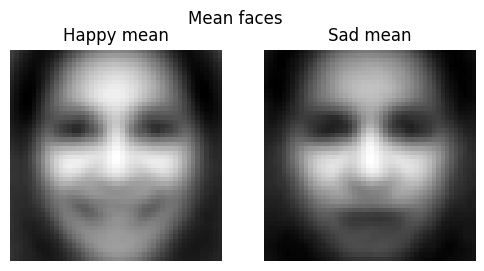

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

img_happy = reconstruct(happy_mean, pca)
axes[0].imshow(img_happy, cmap='gray')
axes[0].set_title(f'Happy mean')
axes[0].axis('off')

img_sad = reconstruct(sad_mean, pca)
axes[1].imshow(img_sad, cmap='gray')
axes[1].set_title(f'Sad mean')
axes[1].axis('off')

plt.suptitle('Mean faces')
plt.show()

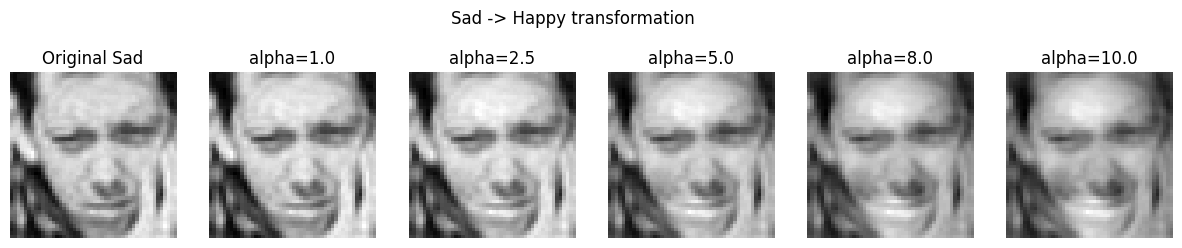

In [36]:
sad_idx = 10
original_sad = sad_pca[sad_idx]

alphas = [1.0, 2.5, 5.0, 8.0, 10.0]

fig, axes = plt.subplots(1, len(alphas) + 1, figsize=(15, 3))

original_sad_img = reconstruct(original_sad, pca)
axes[0].imshow(original_sad_img, cmap='gray')
axes[0].set_title('Original Sad')
axes[0].axis('off')

for ax, alpha in zip(axes[1:], alphas):
    modified_latent = original_sad + alpha * direction_sad_to_happy
    img = reconstruct(modified_latent, pca)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'alpha={alpha}')
    ax.axis('off')

plt.suptitle('Sad -> Happy transformation')
plt.show()

### Happy -> Sad

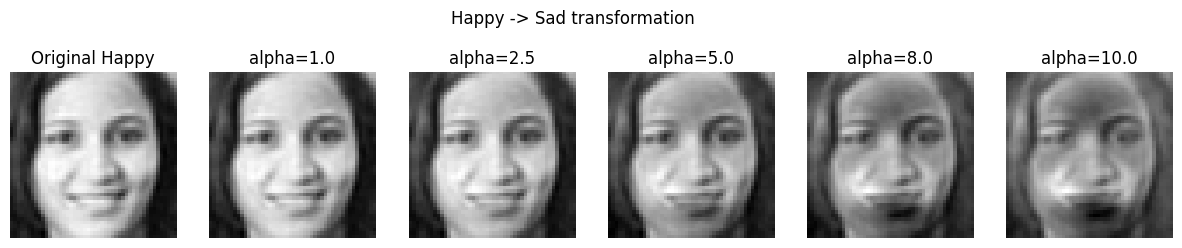

In [53]:
happy_idx = 10
original_happy = happy_pca[happy_idx]

fig, axes = plt.subplots(1, len(alphas) + 1, figsize=(15, 3))

original_happy_img = reconstruct(original_happy, pca)
axes[0].imshow(original_happy_img, cmap='gray')
axes[0].set_title('Original Happy')
axes[0].axis('off')

for ax, alpha in zip(axes[1:], alphas):
    modified_latent = original_happy - alpha * direction_sad_to_happy
    img = reconstruct(modified_latent, pca)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'alpha={alpha}')
    ax.axis('off')

plt.suptitle('Happy -> Sad transformation')
plt.show()